In [ ]:
#import package
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [ ]:
###Data load
notebook_dir = Path.cwd()
retail_dir = notebook_dir.parent
if not (retail_dir / "src" / "data_load_retail.py").exists():
    retail_dir = notebook_dir.parent.parent

os.chdir(retail_dir)
from src.data_load_retail import load_credit_data, apply_labels, CODE_LABELS


df = load_credit_data()
df = apply_labels(df)

In [ ]:
#Numeric values statistic
numeric_cols = df.select_dtypes(include="number").columns
print(df[numeric_cols].describe().T)

In [ ]:
#Some check of the character variables
for col in CODE_LABELS:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

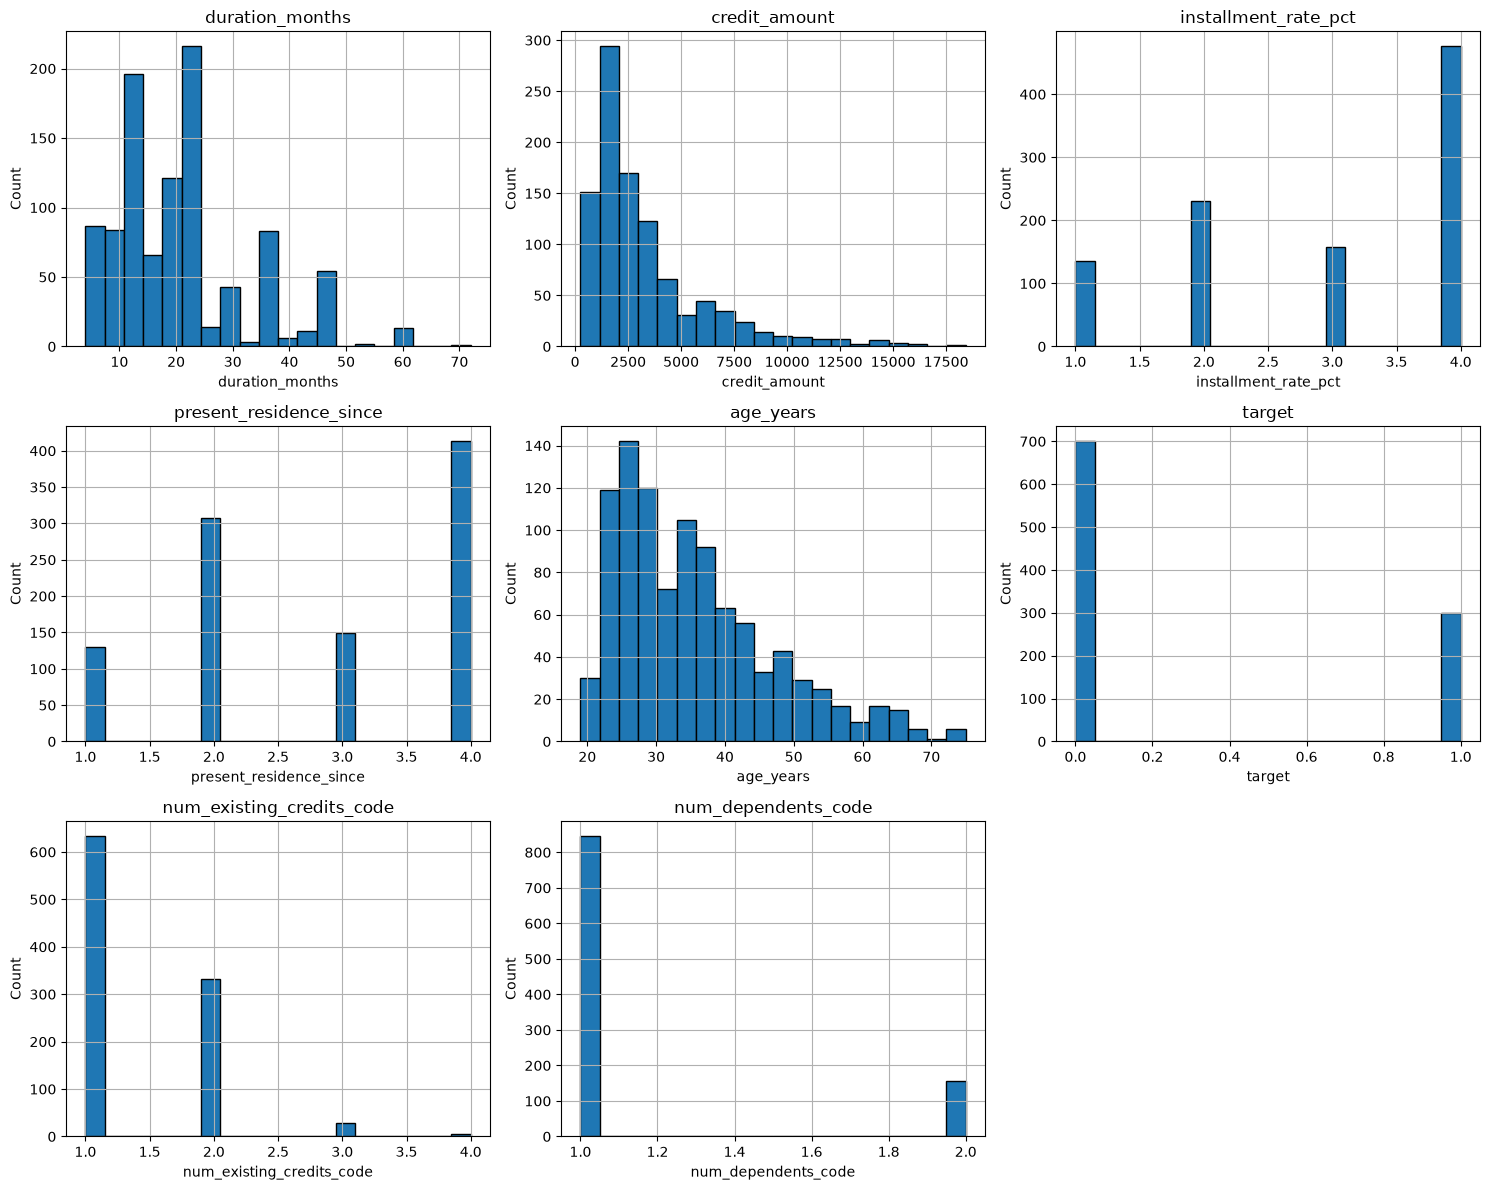

In [32]:
# Histogram of each numeric variable
numeric_cols = df.select_dtypes(include='number').columns

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = np.ravel(axes)

for ax, col in zip(axes, numeric_cols):
    df[col].hist(ax=ax, bins=20, edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

for ax in axes[len(numeric_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()



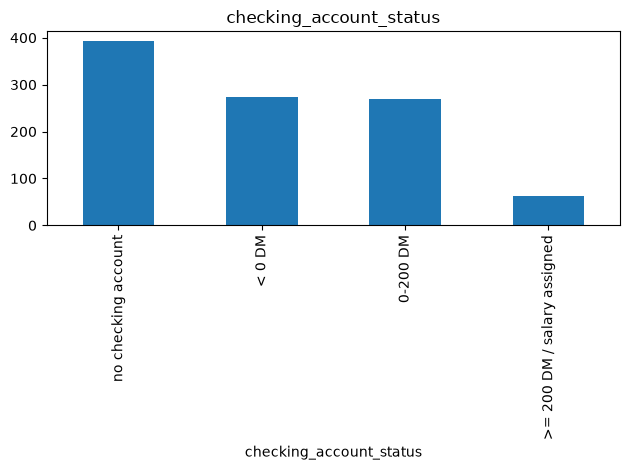

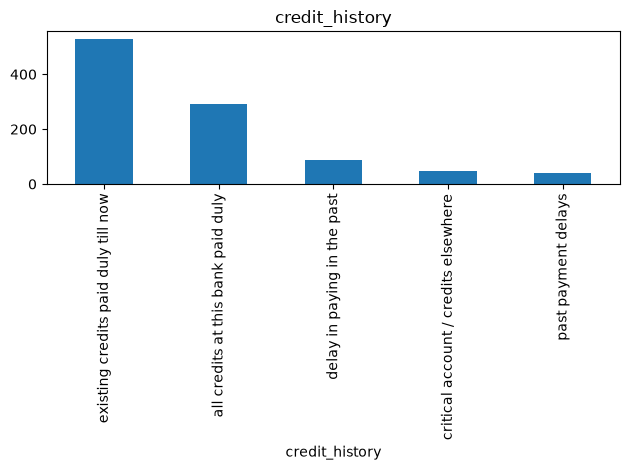

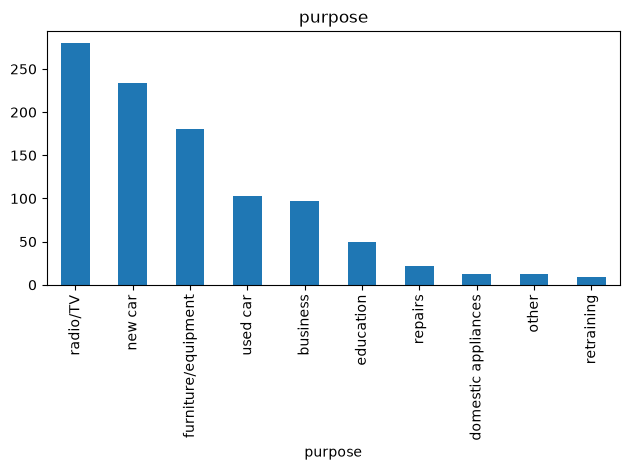

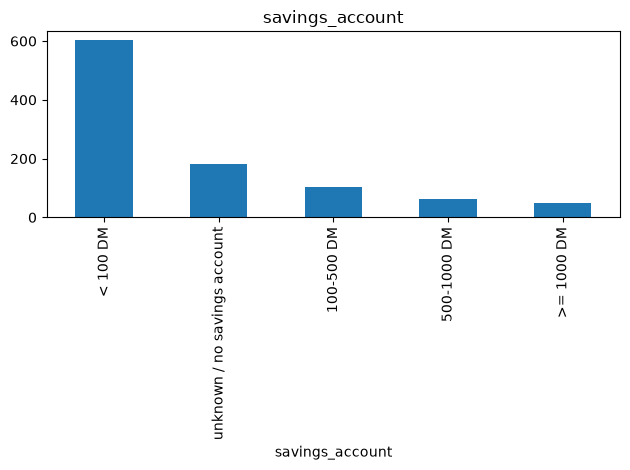

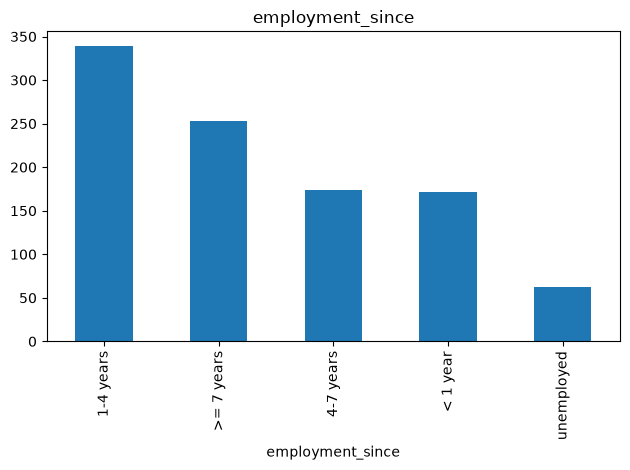

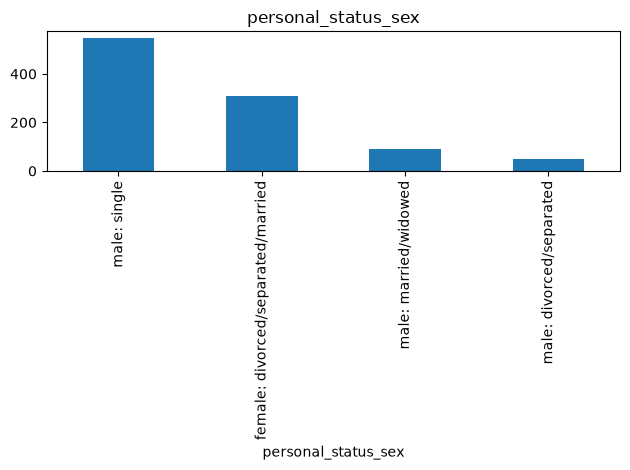

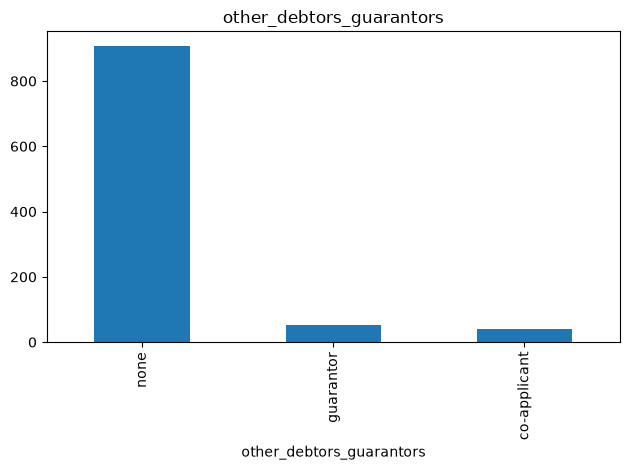

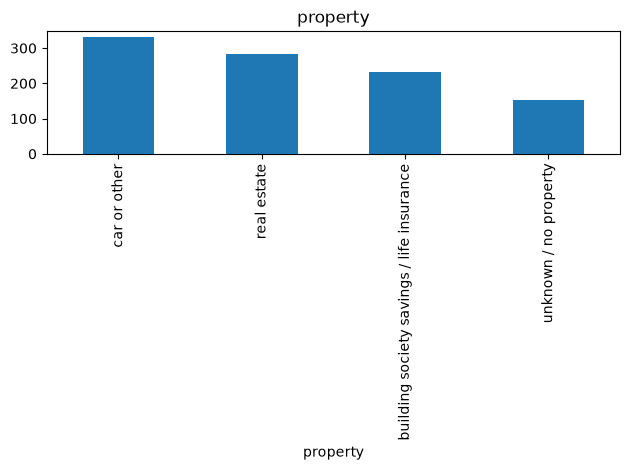

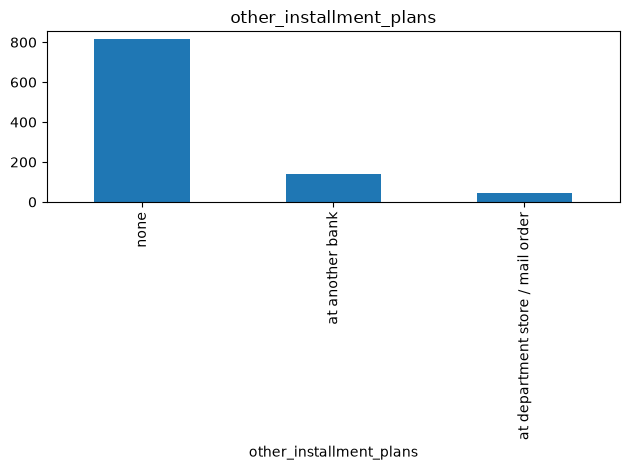

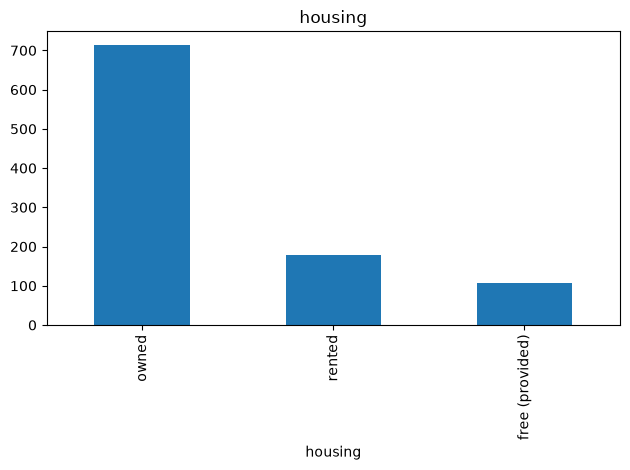

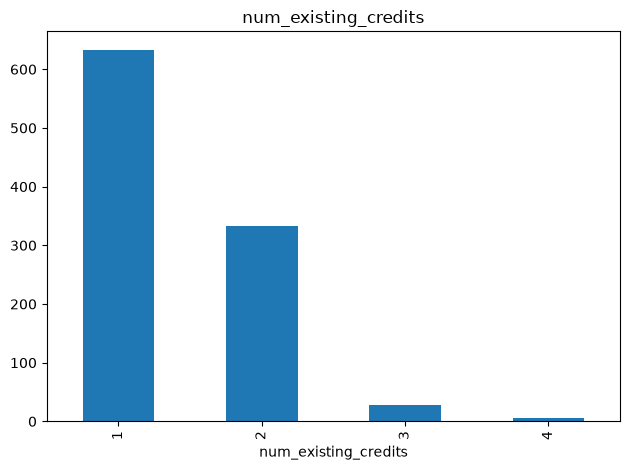

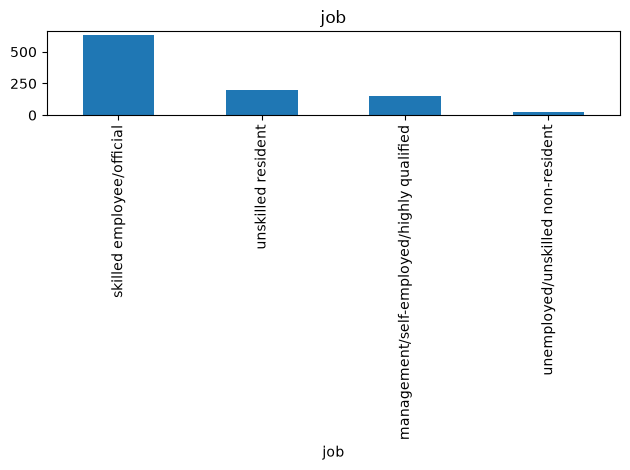

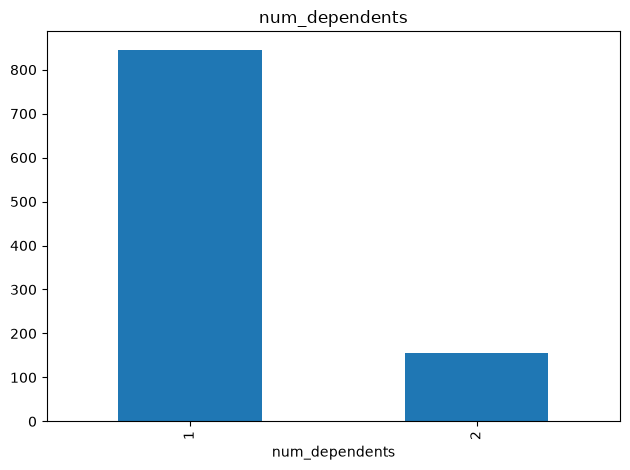

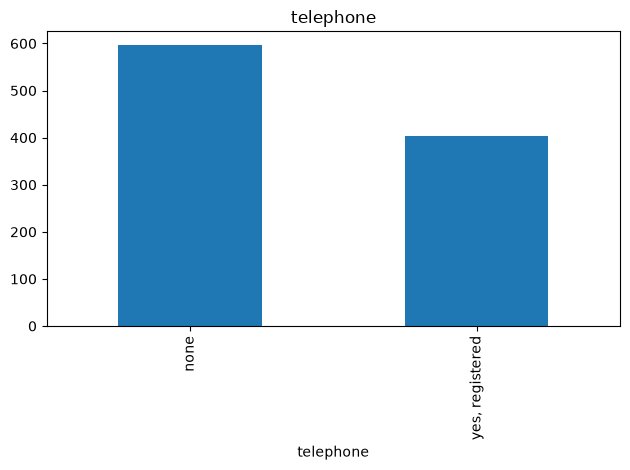

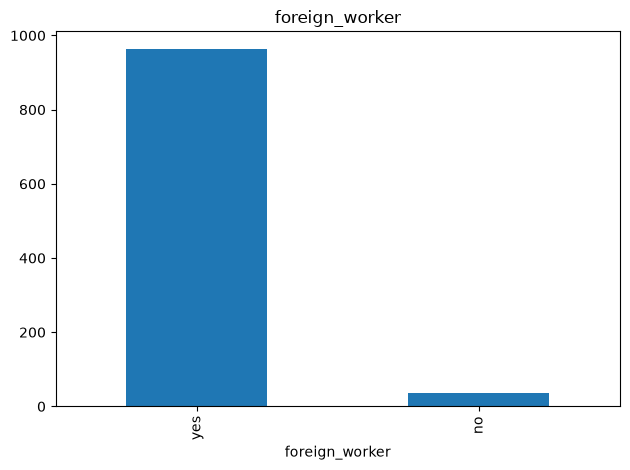

In [35]:
# Summary for each code-labeled categorical variable
cat_cols = [c for c in df.select_dtypes(include=["object", "string"]).columns if not c.endswith("_code")]

for col in cat_cols:
    df[col].value_counts().plot(kind="bar", title=col)
    plt.tight_layout()
    plt.show()